### Global Imports of libraries

In [25]:
from scipy.sparse.linalg import minres
import numpy as np
import torch.nn as nn
import torch
import torch.fft
import matplotlib.pyplot as plt
import math
from scipy.stats import norm
from torch.utils.data import DataLoader, TensorDataset, random_split
from neuralop.models import FNO


## Introduction to FNO(Fourier Neural Operators)

### 1) Defining x and using Fourier Transform

tensor(2.9802e-07)


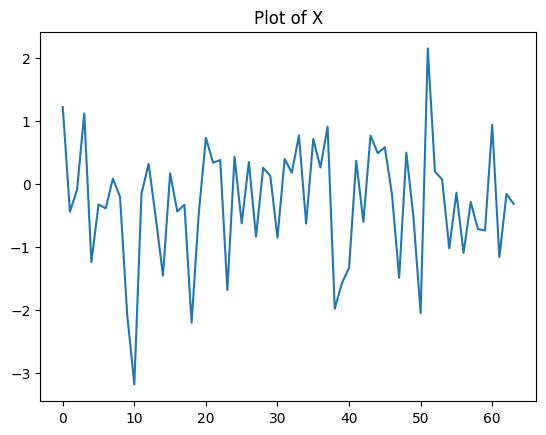

In [ ]:
n = 64
x = torch.randn(n)
x_ft = torch.fft.rfft(x)
x_rec = torch.fft.irfft(x_ft)
print(torch.max(torch.abs(x-x_rec)))
plt.title("Plot of X")
plt.plot(x)

### Truncating x and plotting the smooth function

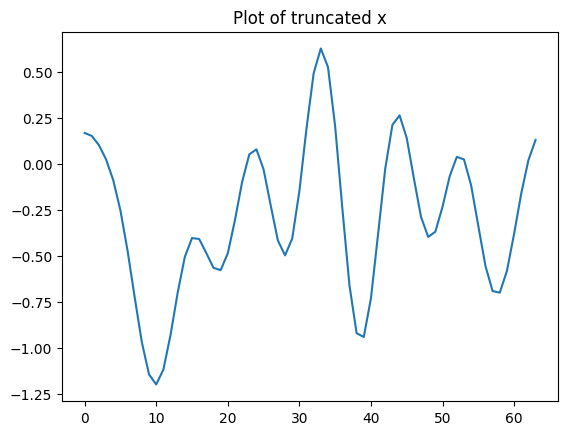

In [ ]:
modes = 8
x_ft_truncated = x_ft.clone()
x_ft_truncated[modes:] = 0.0
x_smooth = torch.fft.irfft(x_ft_truncated,n=n)
plt.title("Plot of truncated x")
plt.plot(x_smooth)

### 2) Multiply each low-frequency Fourier mode by a learnable scalar
Mathematically $$ $\hat{x}(k) \rightarrow w_k \cdot \hat{x}(k) $$

In [ ]:
class LearnableSpectralFilter1D(nn.Module):
    def __init__(self,modes):
        super().__init__()
        self.modes = modes
        self.weights = nn.Parameter(torch.randn(modes,dtype=torch.cfloat))

    def forward(self,x):
        """
        x: (n,)
        """
        n = x.shape[0]
        x_ft = torch.fft.rfft(x)
        out_ft = x_ft.clone()
        out_ft[:self.modes] = out_ft[:self.modes]*self.weights
        out_ft[self.modes:] = 0.0
        x_out = torch.fft.irfft(out_ft,n=n)

        return x_out


### 3) Adding Multiple Channels
>“An FNO layer is a frequency-wise linear operator that mixes channels using complex matrices, followed by an inverse FFT.”

In [ ]:
class SpectralConv1d(nn.Module):
    def __init__(self,in_channels,out_channels,modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.weights = nn.Parameter((torch.randn(in_channels,out_channels,modes,dtype=torch.cfloat)))

    def forward(self,x):
        """
        x : (batch,in_channels,n)
        """
        batch,_,n = x.shape
        x_ft = torch.fft.rfft(x,dim=-1)
        out_ft = torch.zeros(batch,self.out_channels,x_ft.size(-1),device=x.device,dtype=torch.cfloat)
        out_ft[:,:,:self.modes] = torch.einsum("bik,iok->bok",x_ft[:,:,:self.modes],self.weights)
        x_out = torch.fft.irfft(out_ft,n=n,dim=-1)

        return x_out


**Now Lets use this to do something, lets try to learn the operator below**
$ u(x)=sin(x)⟶v(x)=sin(x+ϕ) $


In [ ]:
def generate_batch(batch_size,n):
    x = torch.linspace(0,2*math.pi,n)
    u = torch.sin(x)[None,None,:].repeat(batch_size,1,1)
    v = torch.sin(x+0.5)[None,None,:].repeat(batch_size,1,1)
    return u,v

### Lets define the model

In [ ]:
model = SpectralConv1d(in_channels=1,out_channels=1,modes=8)

### 4) Training Loop

In [ ]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-2)
loss_fn = torch.nn.MSELoss()

n=64

for step in range(500):
    u,v = generate_batch(batch_size=16,n=n)

    pred = model(u)
    loss = loss_fn(pred,v)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step() #Updates the weights

    if step%50==0:
        print(step,loss.item())


0 0.529757022857666
50 0.08176907896995544
100 0.003782884916290641
150 0.000140412274049595
200 0.00010913400910794735
250 0.00010688260226743296
300 0.00010630767064867541
350 0.00010617550287861377
400 0.00010614999337121844
450 0.00010614588973112404


### 5) Lets visualize our results

In [ ]:
n = 64
x = torch.linspace(0, 2 * math.pi, n)
u, v = generate_batch(1, n)
pred = model(u).detach()[0, 0]

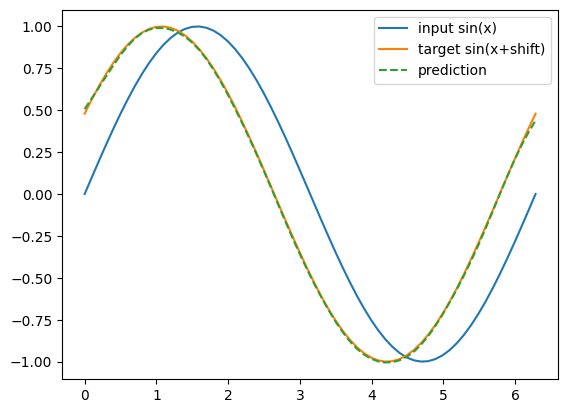

In [ ]:
plt.figure()
plt.plot(x,u[0,0],label="input sin(x)")
plt.plot(x,v[0,0],label="target sin(x+shift)")
plt.plot(x,pred,"--",label="prediction")
plt.legend()
plt.show()

### 6) Learning a nonlinear operator like below
       u(x)⟶u(x)2

In [ ]:
class SimpleFNO1d(nn.Module):
    def __init__(self,modes,width):
        super().__init__()
        self.lift = nn.Linear(1,width)
        self.spectral = SpectralConv1d(width,width,modes)
        self.proj = nn.Linear(width,1)

    def forward(self,x):
        x = x.permute(0,2,1)
        x = self.lift(x)
        x = x.permute(0,2,1)

        x = self.spectral(x)
        x = torch.relu(x)

        x = x.permute(0,2,1)
        x = self.proj(x)
        return x.permute(0,2,1)

In [ ]:
def generate_batch2(batch_size,n):
    x = torch.linspace(0,2*math.pi,n)
    u = torch.sin(x)[None,None,:].repeat(batch_size,1,1)
    v = u**2
    return u,v

In [ ]:
model = SimpleFNO1d(modes=8,width=16)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-2)
loss_fn = nn.MSELoss()

for step in range(1000):
    u , v = generate_batch2(16,64)
    pred = model(u)
    loss = loss_fn(pred,v)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step%100==0:
        print(step,loss.item())

0 1.3044452667236328
100 5.657461588270962e-05
200 2.0584069716278464e-05
300 1.4260262105381116e-05
400 1.1410933439037763e-05
500 9.803817192732822e-06
600 8.75062687555328e-06
700 8.050380529311951e-06
800 7.581595582450973e-06
900 7.158533662732225e-06


### Plotting the results

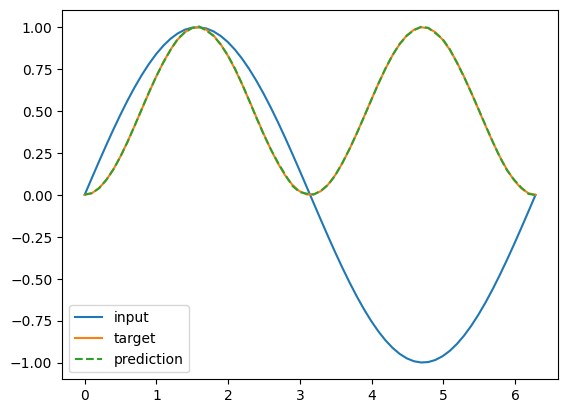

In [ ]:
n = 64
x1 = torch.linspace(0, 2 * math.pi, n)

u1, v1 = generate_batch2(1, n)      # one function
pred = model(u1).detach()         # trained model output

plt.plot(x1, u1[0, 0], label="input")
plt.plot(x1, v1[0, 0], label="target")
plt.plot(x1, pred[0, 0], "--", label="prediction")
plt.legend()
plt.show()

**Right, So until now we have used the FNO to learn and predict basic operators, now lets move on to do something useful with them**

## **Learning to predict option prices using Black-Scholes PDE and FNO**

Black-Scholes Call Option Formula

$C=S_{t}N(d_{1})-Ke^{-rT}N(d_{2})$


* C	=	call option price
* N	=	CDF of the normal distribution
* $S_{t}$	=	spot price of an asset
* K	=	strike price
* r	=	risk-free interest rate
* T	=	time to maturity
* $\sigma$	=	volatility of the asset

d1 and d2 have seperate formulas

In [ ]:
def black_scholes_call(S,K,T,r,sigma):
    if T==0:
        return np.maximum(S-K,0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

In [ ]:
S_grid = np.linspace(1.0, 200.0, 256, dtype=np.float32)
N = 5000

# Preallocate
X = np.empty((N, 256, 4), dtype=np.float32)
Y = np.empty((N, 256, 1), dtype=np.float32)

for i in range(N):
    sigma = np.random.uniform(0.1, 0.6)
    r     = np.random.uniform(0.0, 0.05)
    T     = np.random.uniform(0.1, 2.0)
    K     = np.random.uniform(50, 150)

    prices = black_scholes_call(S_grid, K, T, r, sigma).astype(np.float32)

    X[i, :, 0] = sigma
    X[i, :, 1] = r
    X[i, :, 2] = T
    X[i, :, 3] = K

    Y[i, :, 0] = prices

# Convert once
X = torch.from_numpy(X)   # (N, 256, 4)
Y = torch.from_numpy(Y)   # (N, 256, 1)


In [ ]:
# Dataset
dataset = TensorDataset(X, Y)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


**This dataset now represents the operator**
(σ,r,T,K,S)↦u(S)

and can be evaluated by learning using our FNO at any resolution by sampling different S values

### Defining a basic model Using the Neural Operator Standard Library

In [ ]:
# Model
model = FNO(
    n_modes=(16,),
    hidden_channels=64,
    in_channels=4,
    out_channels=1,
    n_layers=4
).to(device)

### training loop


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=5, factor=0.5
)
loss_fn = torch.nn.MSELoss()

epochs = 50
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device).permute(0, 2, 1)  # (B, 4, 256)
        yb = yb.to(device).permute(0, 2, 1)  # (B, 1, 256)

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device).permute(0, 2, 1)
            yb = yb.to(device).permute(0, 2, 1)

            val_loss += loss_fn(model(xb), yb).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4e} | "
        f"Val Loss: {val_loss:.4e}"
    )


Epoch 000 | Train Loss: 9.8001e+02 | Val Loss: 8.1895e+01
Epoch 001 | Train Loss: 6.8907e+01 | Val Loss: 6.9911e+01
Epoch 002 | Train Loss: 5.2297e+01 | Val Loss: 5.9314e+01
Epoch 003 | Train Loss: 4.1324e+01 | Val Loss: 3.2138e+01
Epoch 004 | Train Loss: 3.8245e+01 | Val Loss: 4.4393e+01
Epoch 005 | Train Loss: 3.3978e+01 | Val Loss: 1.8455e+01
Epoch 006 | Train Loss: 1.9338e+01 | Val Loss: 1.6496e+01
Epoch 007 | Train Loss: 1.9310e+01 | Val Loss: 1.7897e+01
Epoch 008 | Train Loss: 1.5481e+01 | Val Loss: 2.0410e+01
Epoch 009 | Train Loss: 1.8056e+01 | Val Loss: 1.7704e+01
Epoch 010 | Train Loss: 1.2602e+01 | Val Loss: 7.6747e+00
Epoch 011 | Train Loss: 1.0549e+01 | Val Loss: 8.3019e+00
Epoch 012 | Train Loss: 1.1013e+01 | Val Loss: 6.4243e+00
Epoch 013 | Train Loss: 7.9712e+00 | Val Loss: 9.9605e+00
Epoch 014 | Train Loss: 7.1255e+00 | Val Loss: 8.1235e+00
Epoch 015 | Train Loss: 5.4195e+00 | Val Loss: 5.1929e+00
Epoch 016 | Train Loss: 6.5051e+00 | Val Loss: 3.4364e+00
Epoch 017 | Tr

### Plotting Training History

In [ ]:
model.eval()

# take one sample from validation set
xb, yb = val_ds[0]

xb = xb.unsqueeze(0).to(device).permute(0, 2, 1)  # (1, 4, 256)
yb = yb.unsqueeze(0).to(device).permute(0, 2, 1)  # (1, 1, 256)

with torch.no_grad():
    pred = model(xb)

In [ ]:
S = S_grid
true_price = yb.squeeze().cpu().numpy()
pred_price = pred.squeeze().cpu().numpy()


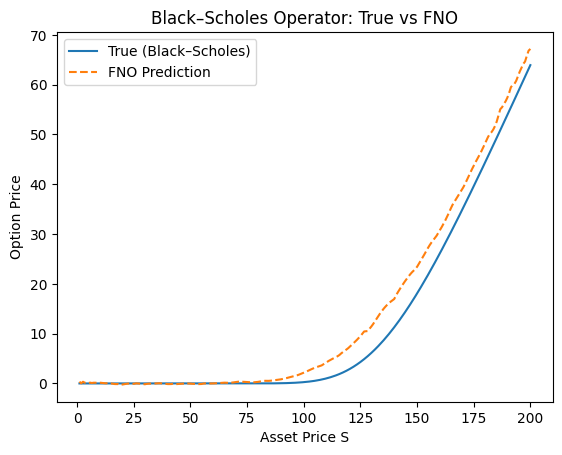

In [ ]:
plt.figure()
plt.plot(S, true_price, label="True (Black–Scholes)")
plt.plot(S, pred_price, "--", label="FNO Prediction")
plt.xlabel("Asset Price S")
plt.ylabel("Option Price")
plt.legend()
plt.title("Black–Scholes Operator: True vs FNO")
plt.show()


## Error Analysis

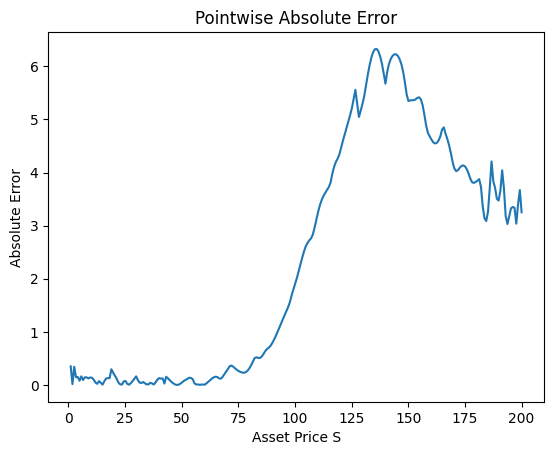

In [26]:
abs_err = np.abs(pred_price - true_price)
rel_err = abs_err / (true_price + 1e-6)

plt.figure()
plt.plot(S, abs_err)
plt.xlabel("Asset Price S")
plt.ylabel("Absolute Error")
plt.title("Pointwise Absolute Error")
plt.show()


In [27]:
rmse = np.sqrt(np.mean((pred_price - true_price)**2))
rel_l2 = np.linalg.norm(pred_price - true_price) / np.linalg.norm(true_price)

print("RMSE:", rmse)
print("Relative L2:", rel_l2)


RMSE: 3.2456734
Relative L2: 0.14970244


In [28]:
errors = []

model.eval()
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device).permute(0, 2, 1)
        yb = yb.to(device).permute(0, 2, 1)

        pred = model(xb)
        err = torch.norm(pred - yb, dim=(1,2)) / torch.norm(yb, dim=(1,2))
        errors.append(err.cpu())

errors = torch.cat(errors)

print("Mean relative L2:", errors.mean().item())
print("90th percentile:", torch.quantile(errors, 0.9).item())


Mean relative L2: 0.026151802390813828
90th percentile: 0.051531169563531876


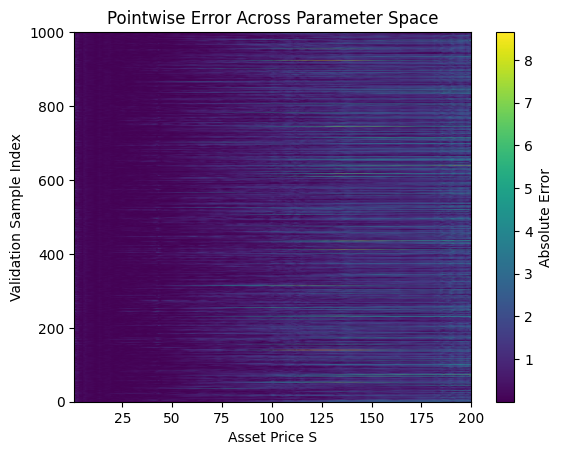

In [30]:
errors = []

model.eval()
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device).permute(0, 2, 1)
        yb = yb.to(device).permute(0, 2, 1)

        pred = model(xb)
        err = torch.abs(pred - yb)          # (B, 1, 256)
        errors.append(err.squeeze(1).cpu())

errors = torch.cat(errors, dim=0).numpy()  # (N_val, 256)

plt.figure()
plt.imshow(errors, aspect="auto", extent=[S.min(), S.max(), 0, errors.shape[0]])
plt.colorbar(label="Absolute Error")
plt.xlabel("Asset Price S")
plt.ylabel("Validation Sample Index")
plt.title("Pointwise Error Across Parameter Space")
plt.show()


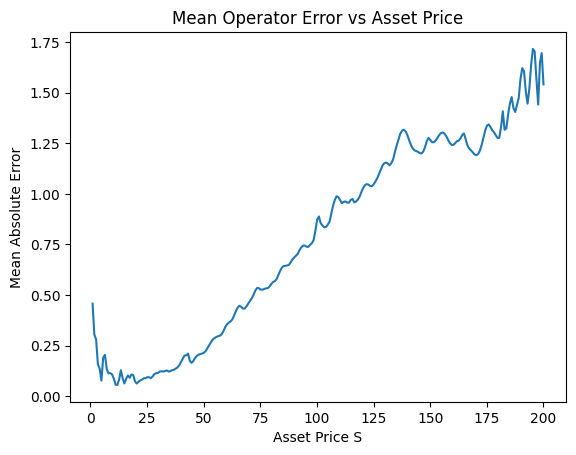

In [31]:
mean_err = errors.mean(axis=0)

plt.figure()
plt.plot(S, mean_err)
plt.xlabel("Asset Price S")
plt.ylabel("Mean Absolute Error")
plt.title("Mean Operator Error vs Asset Price")
plt.show()
